# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

In [1]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-04 09:50:25--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.01s   

2026-05-04 09:50:26 (5.89 MB/s) - ‘wineqr.csv’ saved [84143/84143]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('wineqr.csv')
X = df.drop(columns=['quality'])

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [5]:
X_scaled[0]

array([-0.52835961,  0.96187667, -1.39147228, -0.45321841, -0.24370669,
       -0.46619252, -0.37913269,  0.55827446,  1.28864292, -0.57920652,
       -0.96024611])

In [6]:
#k-means

range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


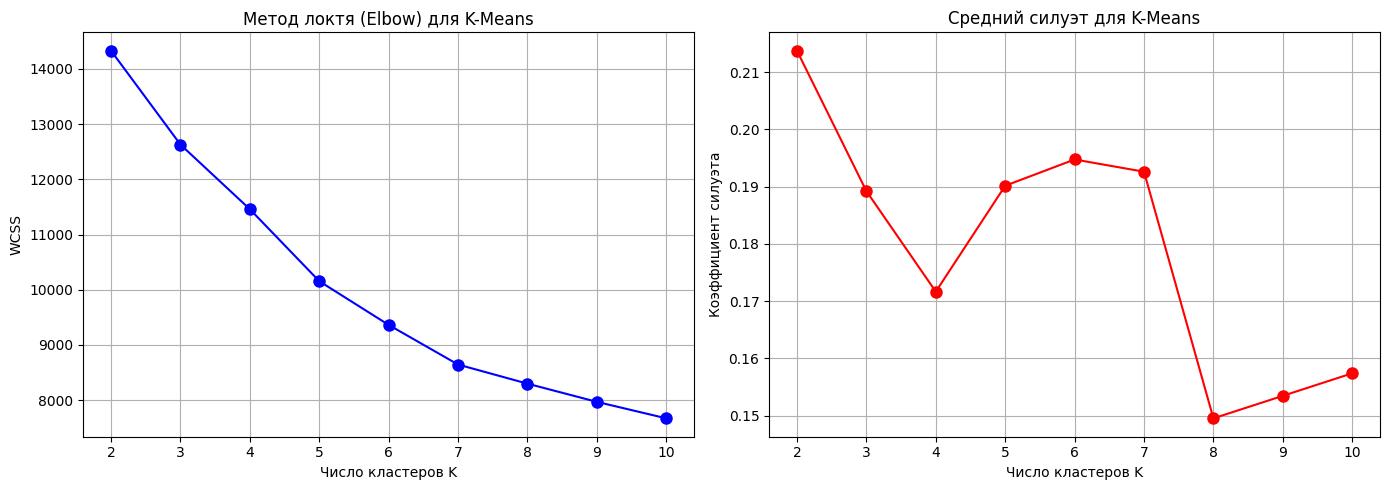

In [7]:
#visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [8]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [9]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

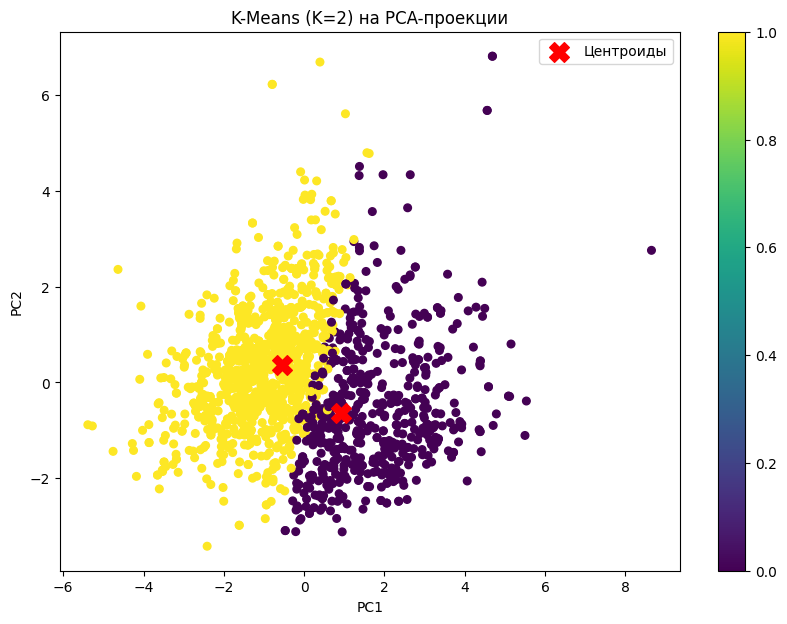

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

### Часть 2. DBSCAN

Silhouette score for the final K-Means model: 0.214


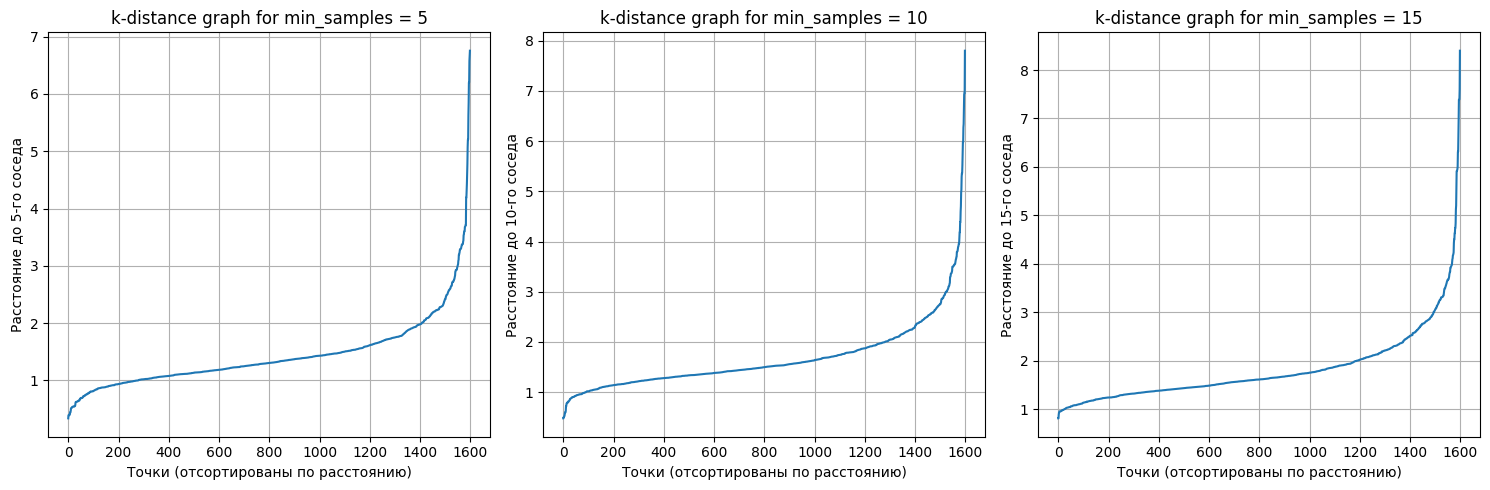


Поиск лучших параметров для DBSCAN:
  eps=0.3, min_samples=5: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.3, min_samples=10: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.3, min_samples=15: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.4, min_samples=5: Clusters=1, Noise=0.99 (Условия не выполнены)
  eps=0.4, min_samples=10: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.4, min_samples=15: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.5, min_samples=5: Clusters=3, Noise=0.99 (Условия не выполнены)
  eps=0.5, min_samples=10: Clusters=1, Noise=0.99 (Условия не выполнены)
  eps=0.5, min_samples=15: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.6, min_samples=5: Clusters=7, Noise=0.97 (Условия не выполнены)
  eps=0.6, min_samples=10: Clusters=1, Noise=0.99 (Условия не выполнены)
  eps=0.6, min_samples=15: Clusters=0, Noise=1.00 (Условия не выполнены)
  eps=0.7, min_samples=5: Clusters=10, Noise=0.95 (Условия не выполнены)
  eps=0.7, min_sam

/tmp/ipykernel_3174/1770464482.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(uniques) - (1 if -1 in uniques else 0))


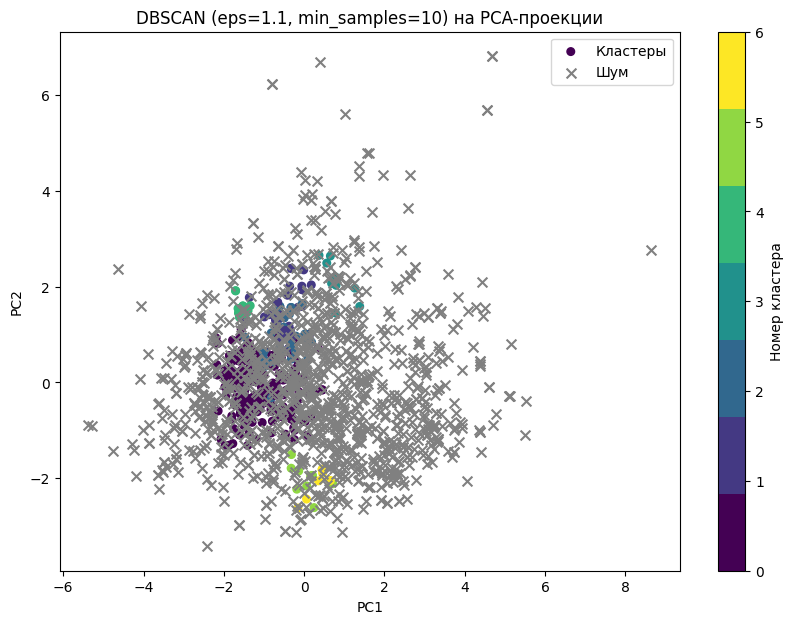

In [12]:
print(f"Silhouette score for the final K-Means model: {silhouette_score(X_scaled, kmeans_labels):.3f}")

# 1. Постройте k-distance graph для min_samples = 5, 10, 15.
plt.figure(figsize=(15, 5))

for i, k_val in enumerate([5, 10, 15]):
    neighbors = NearestNeighbors(n_neighbors=k_val)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    # Сортируем расстояния до k-го соседа (k_val-1, т.к. индексация с 0)
    distances = np.sort(distances[:, k_val-1], axis=0)

    ax = plt.subplot(1, 3, i + 1)
    ax.plot(distances)
    ax.set_title(f'k-distance graph for min_samples = {k_val}')
    ax.set_xlabel('Точки (отсортированы по расстоянию)')
    ax.set_ylabel(f'Расстояние до {k_val}-го соседа')
    ax.grid(True)

plt.tight_layout()
plt.show()

# 2. Методом перебора найдите параметры, дающие максимальный силуэт
best_eps = -1
best_min_samples = -1
max_silhouette = -1
best_dbscan_labels = None

eps_range = np.arange(0.3, 1.2, 0.1)
min_samples_range = [5, 10, 15]

print("\nПоиск лучших параметров для DBSCAN:")
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        total_samples = len(X_scaled)

        # Условия: число кластеров >= 2, шум не более 80% данных
        if n_clusters >= 2 and (n_noise / total_samples) <= 0.8:
            silhouette = silhouette_score(X_scaled, dbscan_labels)
            print(f"  eps={eps:.1f}, min_samples={min_samples}: Clusters={n_clusters}, Noise={n_noise/total_samples:.2f}, Silhouette={silhouette:.3f}")
            if silhouette > max_silhouette:
                max_silhouette = silhouette
                best_eps = eps
                best_min_samples = min_samples
                best_dbscan_labels = dbscan_labels
        else:
            print(f"  eps={eps:.1f}, min_samples={min_samples}: Clusters={n_clusters}, Noise={n_noise/total_samples:.2f} (Условия не выполнены)")

print(f"\nЛучшие параметры для DBSCAN: eps={best_eps:.1f}, min_samples={best_min_samples}, Silhouette={max_silhouette:.3f}")

# 3. Обучите DBSCAN с лучшими параметрами.
if best_eps != -1:
    dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    dbscan_labels_final = dbscan_final.fit_predict(X_scaled)
    print(f"\nФинальная модель DBSCAN обучена с eps={best_eps:.1f} и min_samples={best_min_samples}")
else:
    print("\nНе удалось найти параметры, удовлетворяющие условиям.")
    dbscan_labels_final = np.full(X_scaled.shape[0], -1) # Assign all to noise if no good parameters found

# 4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).
plt.figure(figsize=(10, 7))

# Уникальные метки кластеров, исключая шум (-1)
uniques = np.unique(dbscan_labels_final)
colors = plt.cm.get_cmap('viridis', len(uniques) - (1 if -1 in uniques else 0))

# Разделяем шум и кластеры для визуализации
noise_mask = dbscan_labels_final == -1
cluster_mask = ~noise_mask

# Визуализация кластеров
if np.sum(cluster_mask) > 0:
    scatter_clusters = plt.scatter(
        X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
        c=dbscan_labels_final[cluster_mask], cmap=colors, s=30, label='Кластеры'
    )

# Визуализация шума
if np.sum(noise_mask) > 0:
    plt.scatter(
        X_pca[noise_mask, 0], X_pca[noise_mask, 1],
        c='grey', marker='x', s=50, label='Шум'
    )

plt.title(f'DBSCAN (eps={best_eps:.1f}, min_samples={best_min_samples}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

# Если есть кластеры, добавляем colorbar для них
if np.sum(cluster_mask) > 0:
    cbar = plt.colorbar(scatter_clusters, ticks=np.unique(dbscan_labels_final[cluster_mask]))
    cbar.set_label('Номер кластера')

plt.show()

1. **Почему для DBSCAN критически важно масштабировать данные?**
Метод DBSCAN основан на плотности данных и использует метрики расстояния (например, Евклидово расстояние) для определения соседей. Если масштабирование не сделано и признаки разные, то признак с бОльшим диапазоном значений будет становиться "главным" при расчете расстояний и искажать представление о плотности данных. Масштабирование гарантирует, что все признаки вносят соразмерный вклад в расчет расстояний, и это позволяет алгоритму корректно определять плотные области.

2. **Что будет при слишком маленьком eps? Слишком большом?**

Слишком маленький радус: алгоритм будет считать большинство точек шумом, так как бдет игнорировать все за пределами этого маленького радиуса =>  кластеров будет мало или они будут раздробленными.
Слишком большой: алгоритм может объединить слишком много плотных областей, где много маленьких расстояний между точками, и посчитать их одним кластером, хотя в самом деле это будут разные кластеры. В крайнем случае, вероятно, вообще весь набор данных может быть определен как один большой кластер.

3. **Что означают точки с меткой -1?**

Это шумовые точки или outliers: они не являются ни центральными (core points), ни пограничными (border points) для какого-либо кластера. Вокруг них недостаточно других точек (их количество меньше заданного показателя min_samples) в радиусе eps, чтобы считать их частью кластера.

4. **Чем DBSCAN принципиально отличается от K-Means по форме кластеров?**

K-Means предполагает, что кластеры имеют примерно одинаковый размер и плотность, опирается на центроиды и от них располагает точки в кластеры сферической формы.

DBSCAN может находить кластеры разной формы и плотности. Он группирует точки на основе их плотности и связности, позволяя обнаруживать кластеры, которые K-Means не смог бы распознать.



### Часть 3. OPTICS

Количество найденных кластеров: 1
Количество шумовых точек: 0 (0.0%)
Коэффициент силуэта нельзя рассчитать, недостаточно кластеров или все точки являются шумовыми


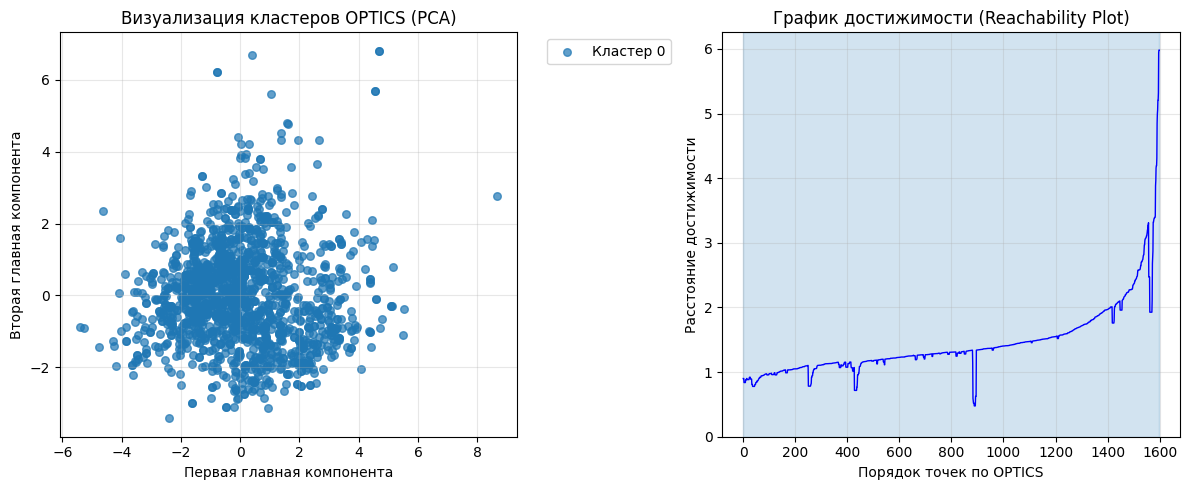

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_samples = X_scaled.shape[0]
min_cluster_size_param = max(2, int(0.05 * n_samples))

optics = OPTICS(min_samples=10,
                xi=0.05,
                min_cluster_size=min_cluster_size_param,
                cluster_method='xi')

# обучение и вывод данных

clusters = optics.fit_predict(X_scaled)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({(n_noise/n_samples)*100:.1f}%)")

if n_clusters >= 2 and n_noise < n_samples:
    mask = clusters != -1
    if mask.sum() >= 2:
        sil_score = silhouette_score(X_scaled[mask], clusters[mask])
        print(f"Коэффициент силуэта: {sil_score:.3f}")
    else:
        print("Недостаточно точек для расчета коэффициента силуэта")
else:
    print("Коэффициент силуэта нельзя рассчитать, недостаточно кластеров или все точки являются шумовыми")

     # визуализация кластеров / PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
unique_clusters = np.unique(clusters)
for cluster in unique_clusters:
    mask = clusters == cluster
    if cluster == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c='gray', label='Шум', alpha=0.5, s=20)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'Кластер {cluster}', alpha=0.7, s=30)
plt.title('Визуализация кластеров OPTICS (PCA)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# визуализация кластеров / reachability plot

plt.subplot(1, 2, 2)
order = optics.ordering_
reachability = optics.reachability_[order]

plt.plot(range(len(reachability)), reachability, 'b-', linewidth=1)

cluster_boundaries = []
current_cluster = clusters[order[0]]
start_idx = 0

for i, idx in enumerate(order):
    if clusters[idx] != current_cluster:
        if current_cluster != -1:
            cluster_boundaries.append((current_cluster, start_idx, i-1))
        start_idx = i
        current_cluster = clusters[idx]

if current_cluster != -1:
    cluster_boundaries.append((current_cluster, start_idx, len(order)-1))


colors = plt.cm.tab10(np.linspace(0, 1, n_clusters)) if n_clusters > 0 else []
for cluster_num, (cluster_id, start, end) in enumerate(cluster_boundaries):
    if cluster_id != -1:
        plt.axvspan(start, end, alpha=0.2, color=colors[cluster_num % len(colors)])

plt.title('График достижимости (Reachability Plot)')
plt.xlabel('Порядок точек по OPTICS')
plt.ylabel('Расстояние достижимости')
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()



1. **Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.**

а. OPTICS строит иерархичную структуру кластеров, что позволяет извлекать их для разных порогов плотности с помощью параметра xi. DBSCAN требует выбора фиксированного eps для каждого запуска, таким образом, получить "слои" невозможно.
b. OPTICS не требует задания eps, а для DBSCAN это обязательно.

2. **Что такое параметр xi (кси) и как он влияет на выделение кластеров?**

xi (кси) — это параметр для автоматического извлечения кластеров из reachability plot в OPTICS. Он определяет минимальную крутизну (перепад) в графике достижимости, которая и должна будет считаться границей кластера. Большее xi ведет к обнаружению более крупных, менее детализированных кластеров; меньшее xi — к большему количеству мелких, более плотных кластеров.

3. **В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.**

OPTICS превосходит DBSCAN, когда целевые данные содержат кластеры с сильно различающейся плотностью. Например, если есть один очень плотный кластер и один более разреженный кластер: DBSCAN либо найдет только плотный кластер (маркируя разреженный как шум), либо объединит их/сделает плотный кластер слишком большим. OPTICS способен обнаружить оба кластера, адаптируясь к их индивидуальной плотности.

4. **Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).**

OPTICS работает медленнее, чем DBSCAN. DBSCAN может быть быстрее, так как не строит всю иерархическую структуру и уже имеет фиксированный eps.

5. **Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?**

Вероятно, K-Means, так как на визуализации PCA для K-Means видно два четко различимых кластера (пусть и с перекрытием), и даже отмечены их центроиды. В DBSCAN очень много шумовых точек (не распознал много областей по плотности), OPTICS определил все данные как один кластер без шума (не нашел релеватного разделения).